
# Annual cylce of TRMM, SSP245, SSP585, and G6sulfur

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator
#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── Helper: extract domain-mean smoothed cycle from one file ──────────────────
# def get_cycle(nc_path, dom, n_doy=365):
#     """Returns smoothed cycle averaged over domain, length n_doy."""
#     ds   = xr.open_dataset(nc_path)
#     lats = ds.lat.values
#     lons = ds.lon.values
#     ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
#     ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
#     sc   = ds["smoothed_cycle"].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     sc[sc == missval] = np.nan
#     cycle = np.nanmean(sc, axis=(1, 2))   # (doy,)
#     ds.close()

#     # Interpolate to common n_doy if needed (e.g. 360 → 365)
#     if len(cycle) != n_doy:
#         x_old = np.linspace(0, 1, len(cycle))
#         x_new = np.linspace(0, 1, n_doy)
#         cycle = np.interp(x_new, x_old, cycle)

#     return np.clip(cycle, 0, None)


def get_cycle(nc_path, dom, n_doy=365):
    ds   = xr.open_dataset(nc_path)
    lats = ds.lat.values
    lons = ds.lon.values

    # ── Normalise lons to match domain convention (0–360) ────────────────────
    if lons.min() < 0:
        lons = np.where(lons < 0, lons + 360, lons)

    lon_min, lon_max = dom["lon"]
    lat_min, lat_max = dom["lat"]

    ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
    ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

    if len(ilat) == 0 or len(ilon) == 0:
        print(f"  WARNING: empty domain for {nc_path.name} — "
              f"lat:{len(ilat)} lon:{len(ilon)}")
        ds.close()
        return np.full(n_doy, np.nan)

    sc = ds["smoothed_cycle"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    sc[sc == missval] = np.nan
    cycle = np.nanmean(sc, axis=(1, 2))
    ds.close()

    if len(cycle) != n_doy:
        x_old = np.linspace(0, 1, len(cycle))
        x_new = np.linspace(0, 1, n_doy)
        cycle = np.interp(x_new, x_old, cycle)

    return np.clip(cycle, 0, None)

In [9]:
# ── Which regions to reindex ──────────────────────────────────────────────────
SH_regions = {"South America", "Southern Africa", "N. Australia"}
AUG1_DOY   = 213   # Aug 1 in a 365-day year

def reindex_cycle(cycle, start_doy):
    """Roll cycle so it starts at start_doy."""
    idx = start_doy - 1   # 0-based
    return np.roll(cycle, -idx)

def make_xticks(start_doy, n_doy=365):
    """Return tick positions and labels starting from start_doy."""
    months = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]
    month_start_doy = [1,32,60,91,121,152,182,213,244,274,305,335]
    ticks, labels = [], []
    for doy, label in zip(month_start_doy, months):
        pos = (doy - start_doy) % n_doy
        ticks.append(pos + 1)
        labels.append(label)
    return ticks, labels

In [17]:
base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

experiments = {
    
    "HIST":   {"color": "gray", "files": [
        "rainy_season_CESM2-WACCM_HIST_1985-2014.nc",
        "rainy_season_CNRM-ESM2-1_HIST_1985-2014.nc",
        "rainy_season_IPSL-CM6A-LR_HIST_1985-2014.nc",
        "rainy_season_MPI-ESM1-2-LR_HIST_1985-2014.nc",
        "rainy_season_UKESM1-0-LL_HIST_1985-2014.nc",
    ]},
    "SSP245":   {"color": "orange", "files": [
        "rainy_season_CESM2-WACCM_SSP245_2071-2100.nc",
        "rainy_season_CNRM-ESM2-1_SSP245_2071-2100.nc",
        "rainy_season_IPSL-CM6A-LR_SSP245_2071-2100.nc",
        "rainy_season_MPI-ESM1-2-LR_SSP245_2071-2100.nc",
        "rainy_season_UKESM1-0-LL_SSP245_2071-2100.nc",
    ]},
    "SSP585":   {"color": "red", "files": [
        "rainy_season_CESM2-WACCM_SSP585_2071-2100.nc",
        "rainy_season_CNRM-ESM2-1_SSP585_2071-2100.nc",
        "rainy_season_IPSL-CM6A-LR_SSP585_2071-2100.nc",
        "rainy_season_MPI-ESM1-2-LR_SSP585_2071-2100.nc",
        "rainy_season_UKESM1-0-LL_SSP585_2071-2100.nc",
    ]},
    "G6sulfur": {"color": "blue", "files": [
        "rainy_season_CESM2-WACCM_G6sulfur_2071-2100.nc",
        "rainy_season_CNRM-ESM2-1_G6sulfur_2071-2100.nc",
        "rainy_season_IPSL-CM6A-LR_G6sulfur_2071-2100.nc",
        "rainy_season_MPI-ESM1-2-LR_G6sulfur_2071-2100.nc",
        "rainy_season_UKESM1-0-LL_G6sulfur_2071-2100.nc",
    ]},
}

trmm_file = base_dir / "rainy_season_TRMM_1998-2019.nc"


# ── One figure per region ─────────────────────────────────────────────────────
n_doy = 365
doys  = np.arange(1, n_doy + 1)

# for region, dom in domains.items():

#     fig, ax = plt.subplots(figsize=(10, 4))

#     # ── TRMM ─────────────────────────────────────────────────────────────────
#     if trmm_file.exists():
#         trmm_cycle = get_cycle(trmm_file, dom, n_doy=n_doy)

#         # ── Reindex SH regions to Aug–Jul ────────────────────────────────────────
#         start_doy = AUG1_DOY if region in SH_regions else 1
    
#         if start_doy != 1:
#             if trmm_file.exists():
#                 trmm_cycle = reindex_cycle(trmm_cycle, start_doy)
#             mme_mean  = reindex_cycle(mme_mean,  start_doy)
#             mme_std   = reindex_cycle(mme_std,   start_doy)
    
#         # ── X-axis ticks ──────────────────────────────────────────────────────────
#         ticks, tick_labels = make_xticks(start_doy, n_doy)
#         ax.set_xticks(ticks)
#         ax.set_xticklabels(tick_labels, fontsize=9)
#         ax.set_xlabel("")
        
#         ax.plot(doys, trmm_cycle, color="black", linewidth=2.5,
#                 label="TRMM", zorder=5)

#     # ── MME per experiment ────────────────────────────────────────────────────
#     for exp_label, exp_meta in experiments.items():
#         color  = exp_meta["color"]
#         cycles = []

#         for fname in exp_meta["files"]:
#             nc_path = base_dir / fname
#             if not nc_path.exists():
#                 print(f"  SKIP {fname}")
#                 continue
#             try:
#                 cycles.append(get_cycle(nc_path, dom, n_doy=n_doy))
#             except Exception as e:
#                 print(f"  ERROR {fname}: {e}")

#         if len(cycles) == 0:
#             continue

#         cycles    = np.array(cycles)          # (n_models, n_doy)
#         mme_mean  = np.nanmean(cycles, axis=0)
#         mme_std   = np.nanstd(cycles,  axis=0)

#         # ── Reindex SH regions to Aug–Jul ────────────────────────────────────────
#         start_doy = AUG1_DOY if region in SH_regions else 1
    
#         if start_doy != 1:
#             if trmm_file.exists():
#                 trmm_cycle = reindex_cycle(trmm_cycle, start_doy)
#             mme_mean  = reindex_cycle(mme_mean,  start_doy)
#             mme_std   = reindex_cycle(mme_std,   start_doy)
    
#         # ── X-axis ticks ──────────────────────────────────────────────────────────
#         ticks, tick_labels = make_xticks(start_doy, n_doy)
#         ax.set_xticks(ticks)
#         ax.set_xticklabels(tick_labels, fontsize=9)
#         ax.set_xlabel("")

#         ax.plot(doys, mme_mean, color=color, linewidth=2,
#                 label=f"{exp_label} MME (n={len(cycles)})")
#         ax.fill_between(doys,
#                         mme_mean - mme_std,
#                         mme_mean + mme_std,
#                         color=color, alpha=0.2)

#     ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
#     ax.set_title(region, fontsize=13, fontweight="bold")
#     # ax.set_xlabel("Day of Year", fontsize=11)

#     ax.set_xticks(ticks)
#     ax.set_xticklabels(tick_labels, fontsize=9)
#     ax.set_xlabel("")
#     ax.set_ylabel("P [mm/day]",  fontsize=11)
#     ax.set_xlim(1, n_doy)
#     # ax.set_ylim(bottom=0)
#     ax.legend(fontsize=9, loc="upper right")
#     ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     safe = region.replace(" ", "_").replace(".", "")
#     outpng = ./ f"smoothed_cycle_MME_{safe}_2071-2100.png"
#     # plt.savefig(outpng, dpi=150, bbox_inches="tight")
#     plt.show()
#     # print(f"Saved → {outpng.name}")

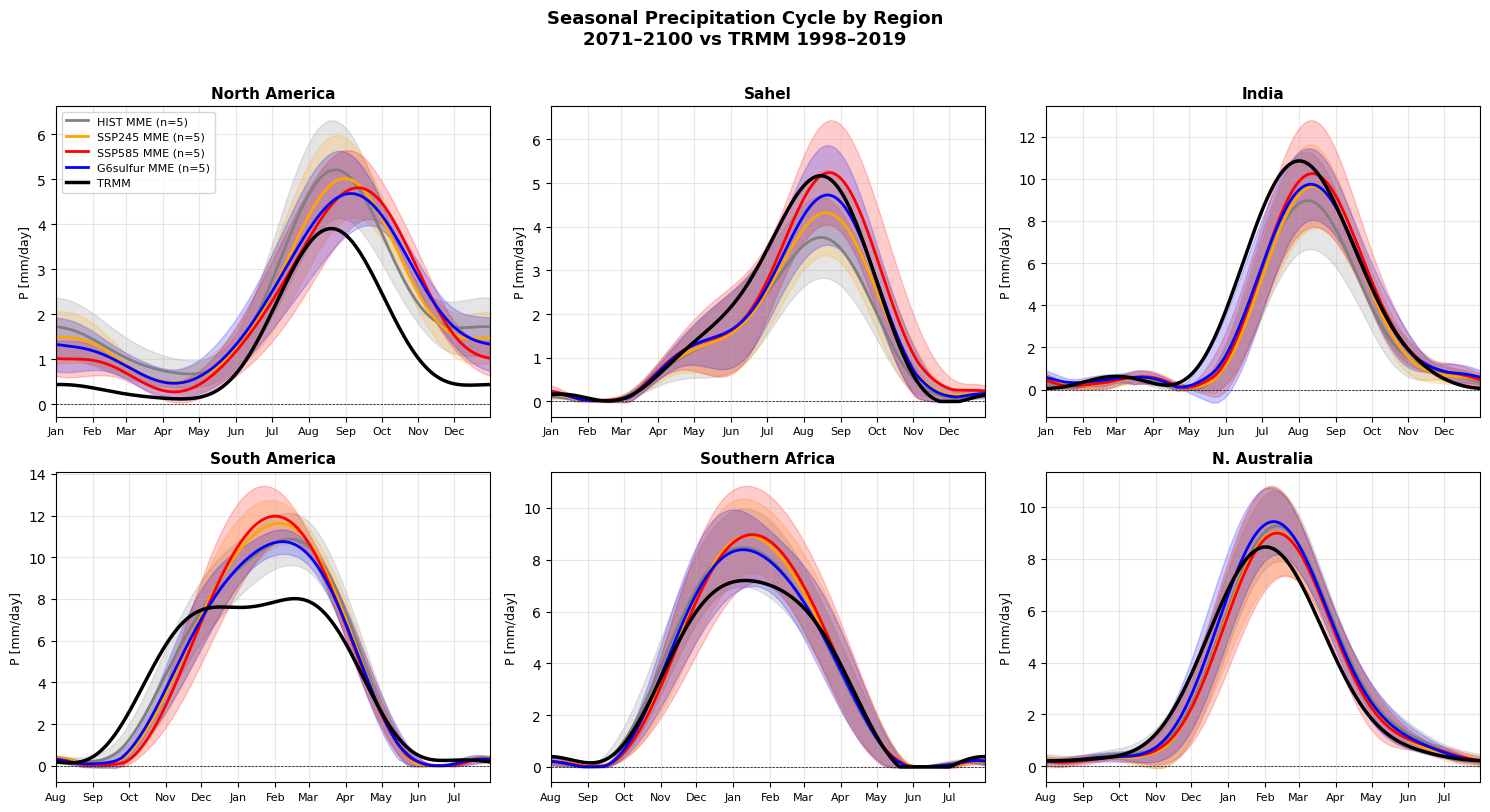

Saved → smoothed_cycle_MME_allregions_2071-2100.png


In [16]:
n_regions = len(domains)
ncols = 3
nrows = (n_regions + ncols - 1) // ncols  # ceiling division = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

for idx, (region, dom) in enumerate(domains.items()):
    ax = axes[idx]

    # ── TRMM ─────────────────────────────────────────────────────────────────
    trmm_cycle = None
    if trmm_file.exists():
        trmm_cycle = get_cycle(trmm_file, dom, n_doy=n_doy)

    # ── MME per experiment ────────────────────────────────────────────────────
    start_doy = AUG1_DOY if region in SH_regions else 1

    for exp_label, exp_meta in experiments.items():
        color  = exp_meta["color"]
        cycles = []

        for fname in exp_meta["files"]:
            nc_path = base_dir / fname
            if not nc_path.exists():
                print(f"  SKIP {fname}")
                continue
            try:
                cycles.append(get_cycle(nc_path, dom, n_doy=n_doy))
            except Exception as e:
                print(f"  ERROR {fname}: {e}")

        if len(cycles) == 0:
            continue

        cycles   = np.array(cycles)
        mme_mean = np.nanmean(cycles, axis=0)
        mme_std  = np.nanstd(cycles,  axis=0)

        if start_doy != 1:
            mme_mean = reindex_cycle(mme_mean, start_doy)
            mme_std  = reindex_cycle(mme_std,  start_doy)

        ax.plot(doys, mme_mean, color=color, linewidth=2,
                label=f"{exp_label} MME (n={len(cycles)})")
        ax.fill_between(doys,
                        mme_mean - mme_std,
                        mme_mean + mme_std,
                        color=color, alpha=0.2)

    # ── TRMM overlay ─────────────────────────────────────────────────────────
    if trmm_cycle is not None:
        if start_doy != 1:
            trmm_cycle = reindex_cycle(trmm_cycle, start_doy)
        ax.plot(doys, trmm_cycle, color="black", linewidth=2.5,
                label="TRMM", zorder=5)

    # ── X-axis ticks ─────────────────────────────────────────────────────────
    ticks, tick_labels = make_xticks(start_doy, n_doy)
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=8)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("P [mm/day]", fontsize=9)
    ax.set_xlim(1, n_doy)
    ax.grid(True, alpha=0.3)

    # Only show legend on first panel
    if idx == 0:
        ax.legend(fontsize=8, loc="upper left")

# Hide unused subplots if n_regions < nrows*ncols
for idx in range(n_regions, nrows * ncols):
    axes[idx].set_visible(False)

# # Shared legend at bottom
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=len(experiments)+1,
#            fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Seasonal Precipitation Cycle by Region\n2071–2100 vs TRMM 1998–2019',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
safe_out = ./ "smoothed_cycle_MME_allregions_2071-2100_1.png"
plt.savefig(safe_out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {safe_out.name}")

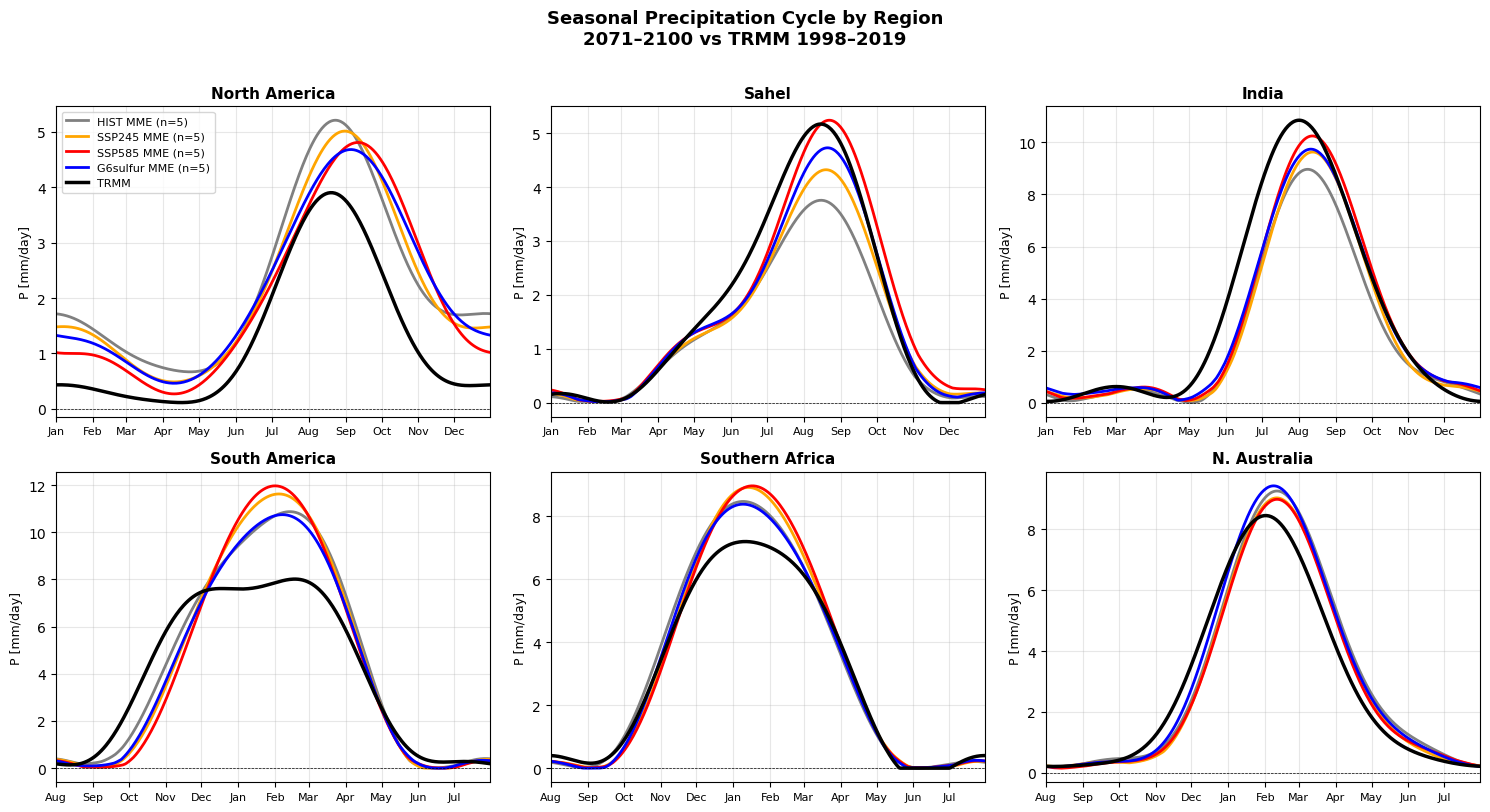

Saved → smoothed_cycle_MME_allregions_2071-2100_2.png


In [22]:
n_regions = len(domains)
ncols = 3
nrows = (n_regions + ncols - 1) // ncols  # ceiling division = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

for idx, (region, dom) in enumerate(domains.items()):
    ax = axes[idx]

    # ── TRMM ─────────────────────────────────────────────────────────────────
    trmm_cycle = None
    if trmm_file.exists():
        trmm_cycle = get_cycle(trmm_file, dom, n_doy=n_doy)

    # ── MME per experiment ────────────────────────────────────────────────────
    start_doy = AUG1_DOY if region in SH_regions else 1

    for exp_label, exp_meta in experiments.items():
        color  = exp_meta["color"]
        cycles = []

        for fname in exp_meta["files"]:
            nc_path = base_dir / fname
            if not nc_path.exists():
                print(f"  SKIP {fname}")
                continue
            try:
                cycles.append(get_cycle(nc_path, dom, n_doy=n_doy))
            except Exception as e:
                print(f"  ERROR {fname}: {e}")

        if len(cycles) == 0:
            continue

        cycles   = np.array(cycles)
        mme_mean = np.nanmean(cycles, axis=0)
        mme_std  = np.nanstd(cycles,  axis=0)

        if start_doy != 1:
            mme_mean = reindex_cycle(mme_mean, start_doy)
            mme_std  = reindex_cycle(mme_std,  start_doy)

        ax.plot(doys, mme_mean, color=color, linewidth=2,
                label=f"{exp_label} MME (n={len(cycles)})")
        # ax.fill_between(doys,
        #                 mme_mean - mme_std,
        #                 mme_mean + mme_std,
        #                 color=color, alpha=0.2)

    # ── TRMM overlay ─────────────────────────────────────────────────────────
    if trmm_cycle is not None:
        if start_doy != 1:
            trmm_cycle = reindex_cycle(trmm_cycle, start_doy)
        ax.plot(doys, trmm_cycle, color="black", linewidth=2.5,
                label="TRMM", zorder=5)

    # ── X-axis ticks ─────────────────────────────────────────────────────────
    ticks, tick_labels = make_xticks(start_doy, n_doy)
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=8)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("P [mm/day]", fontsize=9)
    ax.set_xlim(1, n_doy)
    ax.grid(True, alpha=0.3)

    # Only show legend on first panel
    if idx == 0:
        ax.legend(fontsize=8, loc="upper left")

# Hide unused subplots if n_regions < nrows*ncols
for idx in range(n_regions, nrows * ncols):
    axes[idx].set_visible(False)

# # Shared legend at bottom
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=len(experiments)+1,
#            fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Seasonal Precipitation Cycle by Region\n2071–2100 vs TRMM 1998–2019',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
current_dir = Path.cwd()
safe_out = current_dir / "smoothed_cycle_MME_allregions_2071-2100_2.png"
plt.savefig(safe_out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {safe_out.name}")

In [5]:
# ── Quick check on TRMM grid ──────────────────────────────────────────────────
ds_trmm = xr.open_dataset(trmm_file)
print(f"TRMM lat range: {ds_trmm.lat.values.min():.2f} – {ds_trmm.lat.values.max():.2f}")
print(f"TRMM lon range: {ds_trmm.lon.values.min():.2f} – {ds_trmm.lon.values.max():.2f}")
print(f"TRMM lat size: {ds_trmm.sizes['lat']}, lon size: {ds_trmm.sizes['lon']}")

# Check North America domain specifically
lats = ds_trmm.lat.values
lons = ds_trmm.lon.values
ilat = np.where((lats >= 18.0) & (lats <= 33.0))[0]
ilon = np.where((lons >= 248.0) & (lons <= 258.0))[0]
print(f"\nNorth America: ilat={len(ilat)} points, ilon={len(ilon)} points")
print(f"  lon values in domain: {lons[ilon][:5] if len(ilon)>0 else 'EMPTY'}")
ds_trmm.close()

TRMM lat range: -49.88 – 49.88
TRMM lon range: -179.88 – 179.88
TRMM lat size: 400, lon size: 1440

North America: ilat=60 points, ilon=0 points
  lon values in domain: EMPTY
